In [4]:
import pandas as pd

In [6]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [12]:
df = pd.read_csv("share-energy-consum-by-source.csv")

In [14]:
df_cleaned = df.dropna(subset=['Code'])


In [16]:
features = ['Year', 'Oil (% sub energy)', 'Coal (% sub energy)', 'Nuclear (% sub energy)', 
            'Hydro (% sub energy)', 'Wind (% sub energy)', 'Gas (% sub energy)', 
            'Other renewables (% sub energy)']

In [18]:
target = 'Solar (% sub energy)' 

In [20]:
X = df_cleaned[features]
y = df_cleaned[target]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_pred = model.predict(X_test)


In [28]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


In [30]:
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

MAE: 0.03466086165048544
RMSE: 0.12182302085332683
R² Score: 0.8815860070716659


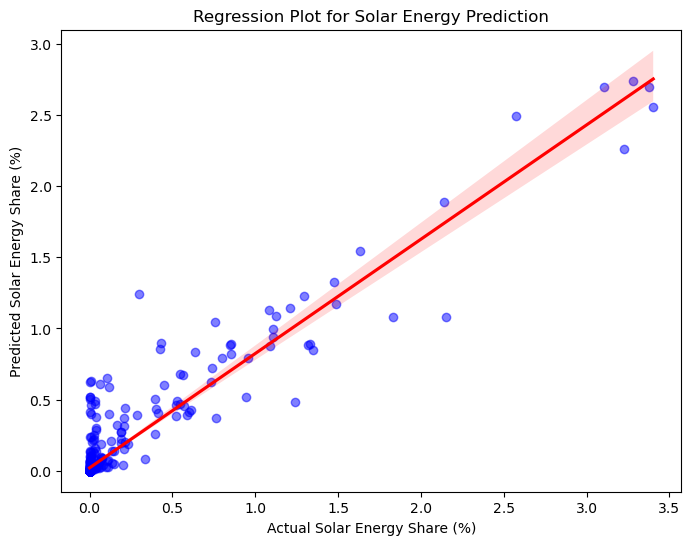

In [32]:
# Plotting Regression Results
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"color": "blue", "alpha": 0.5}, line_kws={"color": "red"})
plt.xlabel("Actual Solar Energy Share (%)")
plt.ylabel("Predicted Solar Energy Share (%)")
plt.title("Regression Plot for Solar Energy Prediction")
plt.show()
